In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

try:
    import umap  # pip install umap-learn
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False

In [2]:
# Настройки отображения
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

# Лабораторная работа: визуализация многомерных данных

Датасет **txhousing**: ежемесячные показатели рынка жилья в городах Техаса.  


In [4]:
# Считываем датасет
df_raw = pd.read_csv('data/txhousing.csv')
df_raw

,Unnamed: 0,city,year,month,sales,volume,median,listings,inventory,date
0,1,Abilene,2000,1,72.0,5380000.0,71400.0,701.0,6.3,2000.000000
1,2,Abilene,2000,2,98.0,6505000.0,58700.0,746.0,6.6,2000.083333
2,3,Abilene,2000,3,130.0,9285000.0,58100.0,784.0,6.8,2000.166667
3,4,Abilene,2000,4,98.0,9730000.0,68600.0,785.0,6.9,2000.250000
4,5,Abilene,2000,5,141.0,10590000.0,67300.0,794.0,6.8,2000.333333
...,...,...,...,...,...,...,...,...,...,...
8597,8598,Wichita Falls,2015,3,152.0,16716584.0,89200.0,818.0,6.8,2015.166667
8598,8599,Wichita Falls,2015,4,129.0,15482194.0,105300.0,760.0,6.4,2015.250000
8599,8600,Wichita Falls,2015,5,174.0,19188181.0,100000.0,776.0,6.4,2015.333333
8600,8601,Wichita Falls,2015,6,143.0,18820752.0,118800.0,770.0,6.2,2015.416667


In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8602 entries, 0 to 8601
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8602 non-null   int64  
 1   city        8602 non-null   object 
 2   year        8602 non-null   int64  
 3   month       8602 non-null   int64  
 4   sales       8034 non-null   float64
 5   volume      8034 non-null   float64
 6   median      7986 non-null   float64
 7   listings    7178 non-null   float64
 8   inventory   7135 non-null   float64
 9   date        8602 non-null   float64
dtypes: float64(6), int64(3), object(1)
memory usage: 672.2+ KB


In [6]:
df_raw.describe()

,Unnamed: 0,year,month,sales,volume,median,listings,inventory,date
count,8602.000000,8602.000000,8602.000000,8034.000000,8.034000e+03,7986.000000,7178.000000,7135.000000,8602.000000
mean,4301.500000,2007.299465,6.406417,549.564600,1.068586e+08,128131.442524,3216.902340,7.174590,2007.750000
std,2483.327841,4.502923,3.441932,1110.737179,2.449337e+08,37359.575317,5968.331072,4.612125,4.498718
min,1.000000,2000.000000,1.000000,6.000000,8.350000e+05,50000.000000,0.000000,0.000000,2000.000000
25%,2151.250000,2003.000000,3.000000,86.000000,1.084000e+07,100000.000000,682.000000,4.900000,2003.833333
50%,4301.500000,2007.000000,6.000000,169.000000,2.298682e+07,123800.000000,1283.000000,6.200000,2007.750000
75%,6451.750000,2011.000000,9.000000,467.000000,7.512139e+07,150000.000000,2953.750000,8.150000,2011.666667
max,8602.000000,2015.000000,12.000000,8945.000000,2.568157e+09,304200.000000,43107.000000,55.900000,2015.500000


## Подготовка данных

В исходном датасете есть категориальный столбец `city` и непрерывный показатель `median` — медианная цена продажи.  
Для задачи визуализации классов сделаем целевую переменную `price_segment`:

- `0` — низкий сегмент медианной цены;
- `1` — средний сегмент;
- `2` — высокий сегмент.

Столбец `median`, из которого создаётся target, удаляем из признаков, чтобы не было прямой утечки целевой переменной. Столбец `city` также удаляем, чтобы сохранить формат лабораторной с числовыми признаками.

In [8]:
# Удаляем пропуски: часть городов/месяцев не содержит всех показателей рынка
df = df_raw.dropna().copy()

# Создаём целевую переменную из медианной цены: три примерно равные группы
df['price_segment'] = pd.qcut(df['median'], q=3, labels=[0, 1, 2]).astype(int)

# Удаляем нечисловой город и исходный столбец, из которого получили target
df = df.drop(columns=['city', 'median'])

print(f'Размер исходного датасета: {df_raw.shape}')
print(f'Размер после удаления пропусков и подготовки target: {df.shape}')
df

Размер исходного датасета: (8602, 10)
Размер после удаления пропусков и подготовки target: (7126, 9)


,Unnamed: 0,year,month,sales,volume,listings,inventory,date,price_segment
0,1,2000,1,72.0,5380000.0,701.0,6.3,2000.000000,0
1,2,2000,2,98.0,6505000.0,746.0,6.6,2000.083333,0
2,3,2000,3,130.0,9285000.0,784.0,6.8,2000.166667,0
3,4,2000,4,98.0,9730000.0,785.0,6.9,2000.250000,0
4,5,2000,5,141.0,10590000.0,794.0,6.8,2000.333333,0
...,...,...,...,...,...,...,...,...,...
8597,8598,2015,3,152.0,16716584.0,818.0,6.8,2015.166667,0
8598,8599,2015,4,129.0,15482194.0,760.0,6.4,2015.250000,0
8599,8600,2015,5,174.0,19188181.0,776.0,6.4,2015.333333,0
8600,8601,2015,6,143.0,18820752.0,770.0,6.2,2015.416667,1


In [9]:
df.describe()

,Unnamed: 0,year,month,sales,volume,listings,inventory,date,price_segment
count,7126.000000,7126.000000,7126.000000,7126.000000,7.126000e+03,7126.000000,7126.000000,7126.000000,7126.000000
mean,4141.130227,2007.913135,6.384788,602.975442,1.182523e+08,3234.968987,7.174418,2008.361867,0.999719
std,2540.986312,4.548703,3.445432,1164.497619,2.572152e+08,5986.145186,4.614505,4.544876,0.816497
min,1.000000,2000.000000,1.000000,6.000000,8.350000e+05,0.000000,0.000000,2000.000000,0.000000
25%,1957.250000,2004.000000,3.000000,95.000000,1.221679e+07,687.000000,4.900000,2004.416667,0.000000
50%,3879.500000,2008.000000,6.000000,187.000000,2.624012e+07,1296.500000,6.200000,2008.916667,1.000000
75%,6397.750000,2012.000000,9.000000,527.000000,8.963242e+07,2968.500000,8.100000,2012.250000,2.000000
max,8602.000000,2015.000000,12.000000,8945.000000,2.568157e+09,43107.000000,55.900000,2015.500000,2.000000


### Удаление выбросов.

In [11]:
q = 0.999

feature_names = [x for x in df.columns if x != 'price_segment']
original_shape = df.shape

for feature in feature_names:
    df = df[df[feature] < df[feature].quantile(q)]

print(f'Размер до удаления выбросов: {original_shape}')
print(f'Размер после удаления выбросов: {df.shape}')
df

Размер до удаления выбросов: (7126, 9)
Размер после удаления выбросов: (6169, 9)


,Unnamed: 0,year,month,sales,volume,listings,inventory,date,price_segment
0,1,2000,1,72.0,5380000.0,701.0,6.3,2000.000000,0
1,2,2000,2,98.0,6505000.0,746.0,6.6,2000.083333,0
2,3,2000,3,130.0,9285000.0,784.0,6.8,2000.166667,0
3,4,2000,4,98.0,9730000.0,785.0,6.9,2000.250000,0
4,5,2000,5,141.0,10590000.0,794.0,6.8,2000.333333,0
...,...,...,...,...,...,...,...,...,...
8588,8589,2014,6,123.0,18250258.0,961.0,8.1,2014.416667,1
8589,8590,2014,7,150.0,18672368.0,941.0,8.0,2014.500000,0
8590,8591,2014,8,137.0,16128962.0,973.0,8.3,2014.583333,0
8591,8592,2014,9,110.0,12014869.0,940.0,8.1,2014.666667,0


In [12]:
df.describe()

,Unnamed: 0,year,month,sales,volume,listings,inventory,date,price_segment
count,6169.000000,6169.000000,6169.000000,6169.000000,6.169000e+03,6169.000000,6169.000000,6169.000000,6169.000000
mean,4125.969849,2007.523586,5.956557,581.952018,1.105484e+08,3239.941482,7.268261,2007.936632,0.962393
std,2546.963493,4.367646,3.151759,1090.408768,2.286483e+08,5923.910143,4.401489,4.372881,0.812643
min,1.000000,2000.000000,1.000000,6.000000,8.350000e+05,0.000000,0.000000,2000.000000,0.000000
25%,1938.000000,2004.000000,3.000000,96.000000,1.217458e+07,700.000000,5.000000,2004.166667,0.000000
50%,3863.000000,2008.000000,6.000000,188.000000,2.626000e+07,1315.000000,6.300000,2008.500000,1.000000
75%,6397.000000,2011.000000,9.000000,527.000000,8.809478e+07,3038.000000,8.200000,2011.750000,2.000000
max,8593.000000,2014.000000,11.000000,8040.000000,1.703806e+09,41214.000000,51.300000,2014.750000,2.000000


### Проверим распределение классов

In [14]:
df['price_segment'].value_counts().sort_index()

price_segment
0    2157
1    2087
2    1925
Name: count, dtype: int64

Классы остались достаточно сбалансированными, поэтому датасет подходит для визуализации различий между группами.

In [16]:
target_class_names_dict = {
    0: 'Low median price',
    1: 'Medium median price',
    2: 'High median price'
}

## Визуализация многомерных данных

Полный датасет остаётся в переменной `df`.  
Для тяжёлых методов вроде t-SNE берём стратифицированную подвыборку, чтобы ноутбук запускался стабильно и не зависал.

Размер полного датасета после очистки: (6169, 9)
Размер подвыборки для визуализаций: (801, 9)
price_segment
0    280
1    271
2    250
Name: count, dtype: int64

Информация о данных:
  Размер: (801, 8)
  Количество классов: 3
  Количество признаков: 8
  Минимум: -1.806, Максимум: 7.364
  Среднее: -0.000, Стандартное отклонение: 1.000
ПОЛНАЯ ВИЗУАЛИЗАЦИЯ МНОГОМЕРНЫХ ДАННЫХ

1. Парные диаграммы рассеяния (PairPlot)


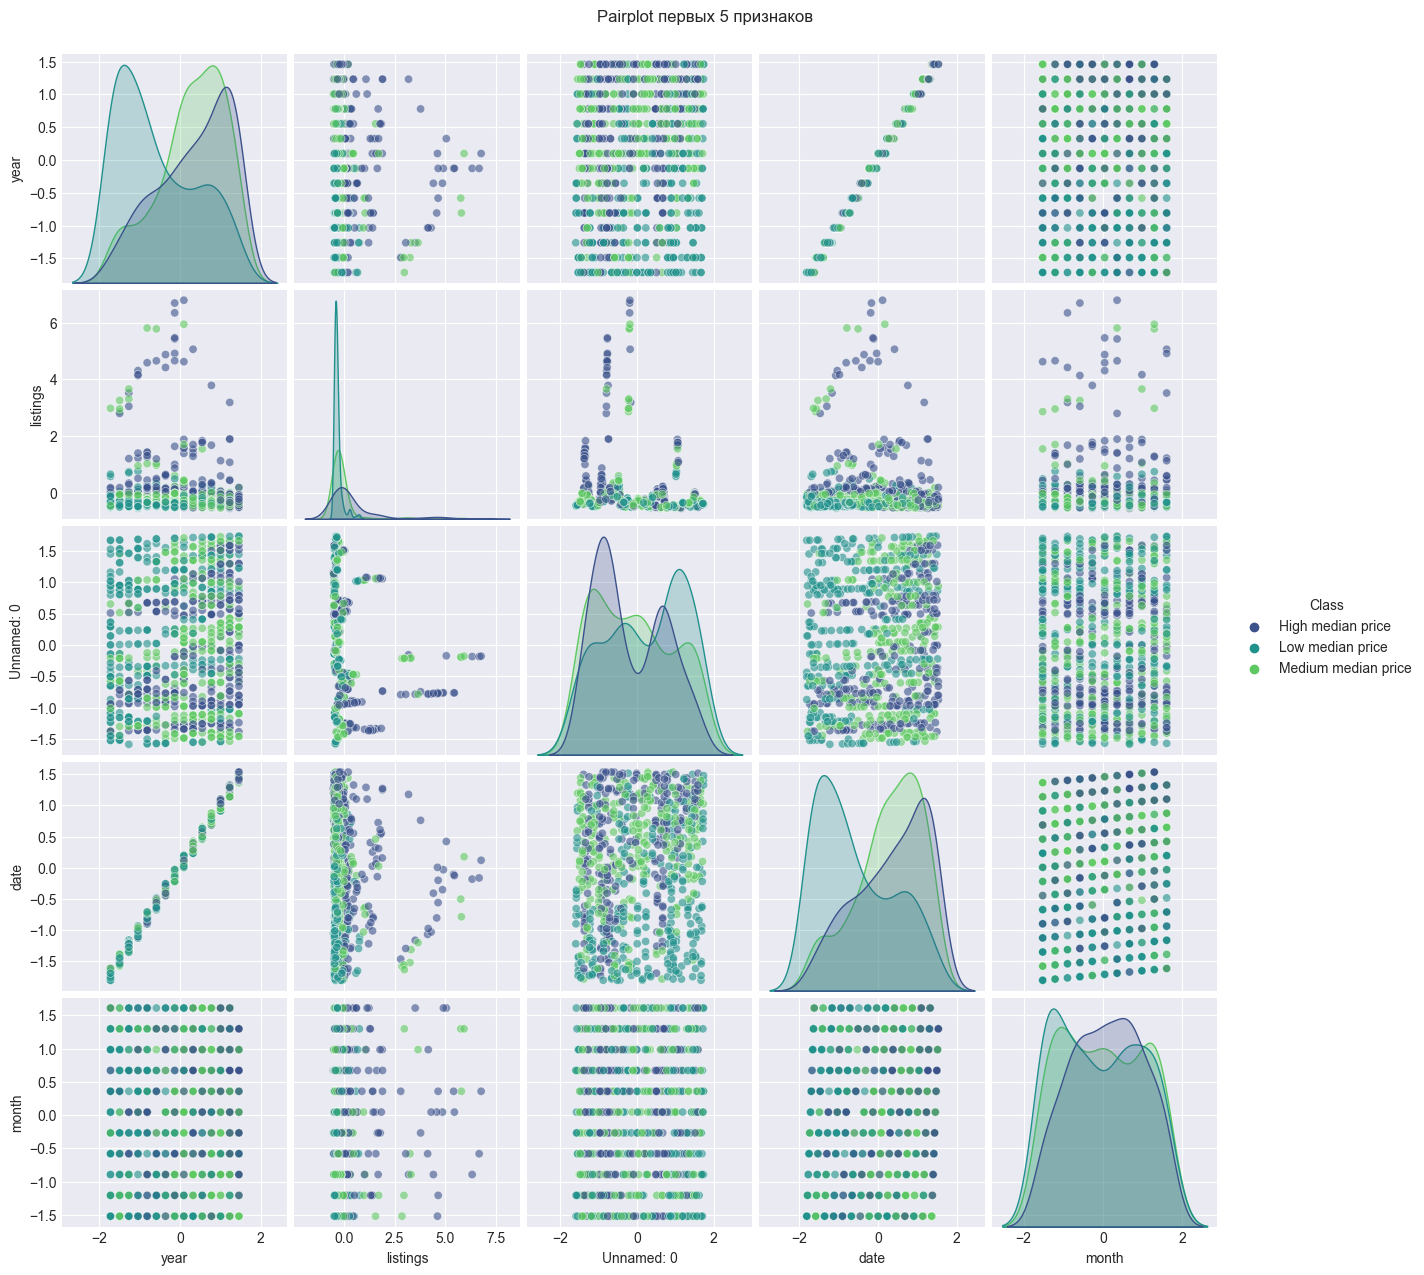


2. Тепловая карта корреляций


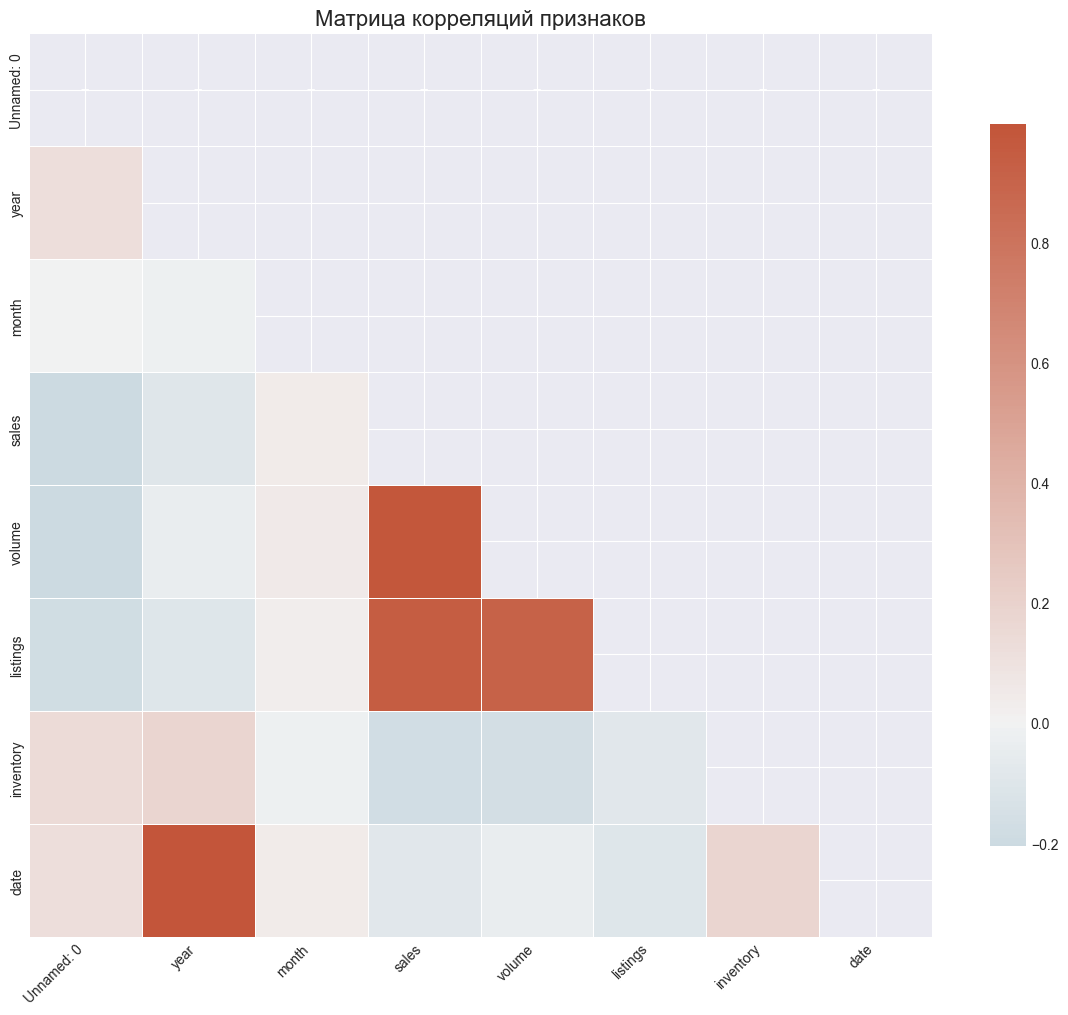


3. Визуализация PCA (2D и 3D)
Объясненная дисперсия: [0.38220576 0.25153225 0.12516453]
Суммарная объясненная дисперсия: 0.759


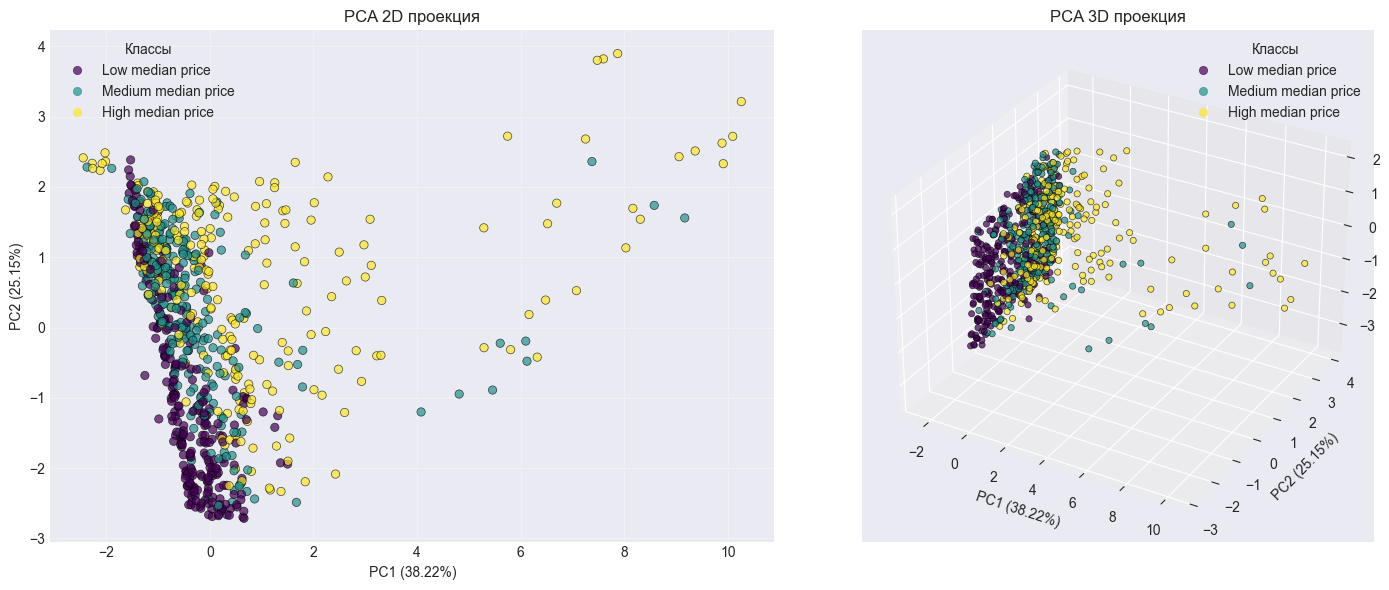

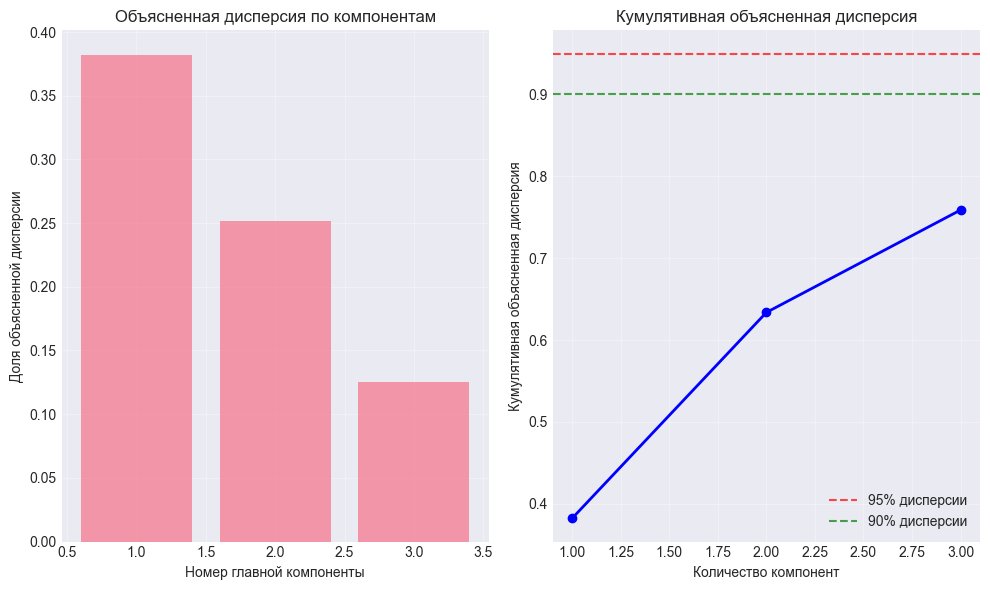


4. Визуализация t-SNE


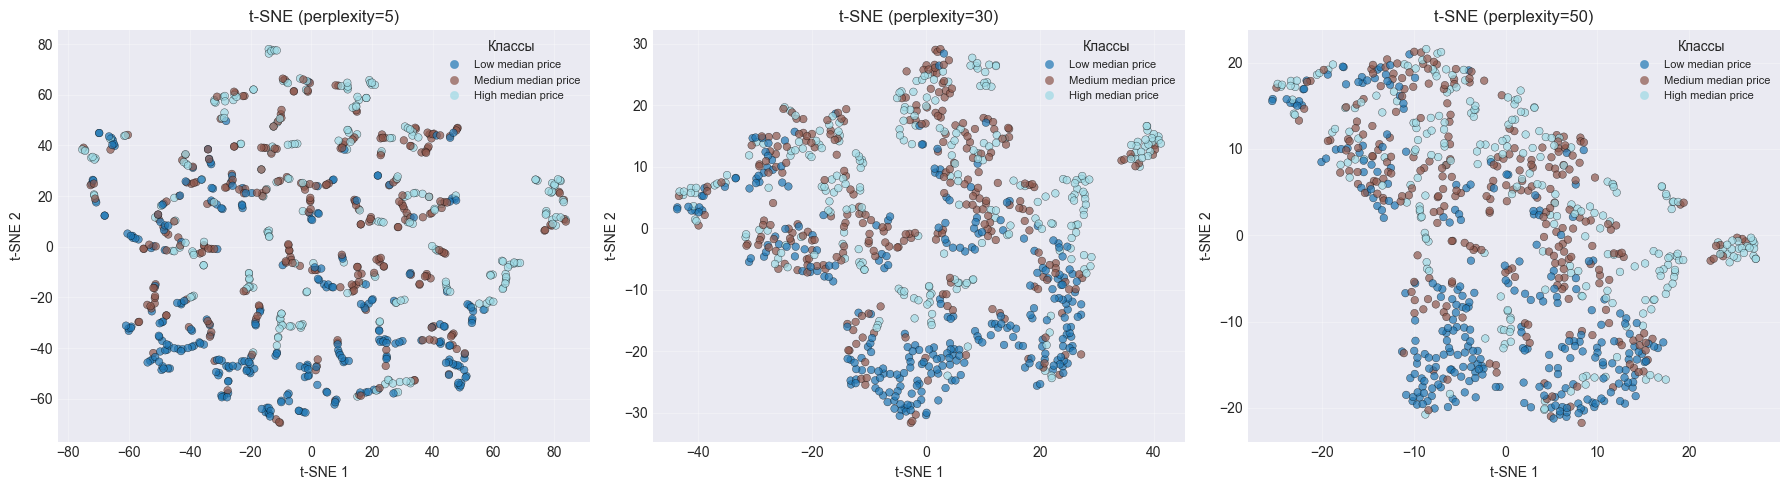


Примечание: Для UMAP визуализации установите: pip install umap-learn

6. Параллельные координаты


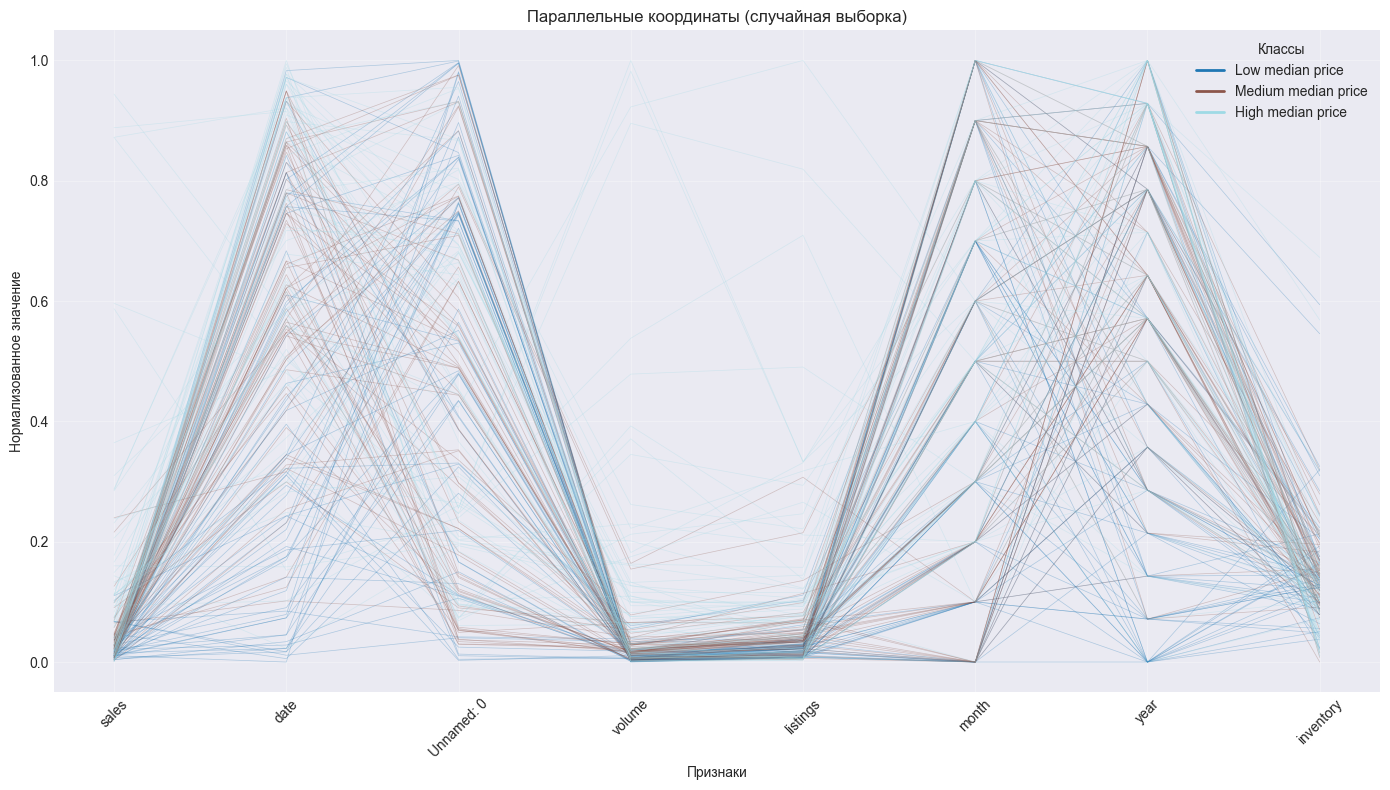


7. Радар-чарты по классам


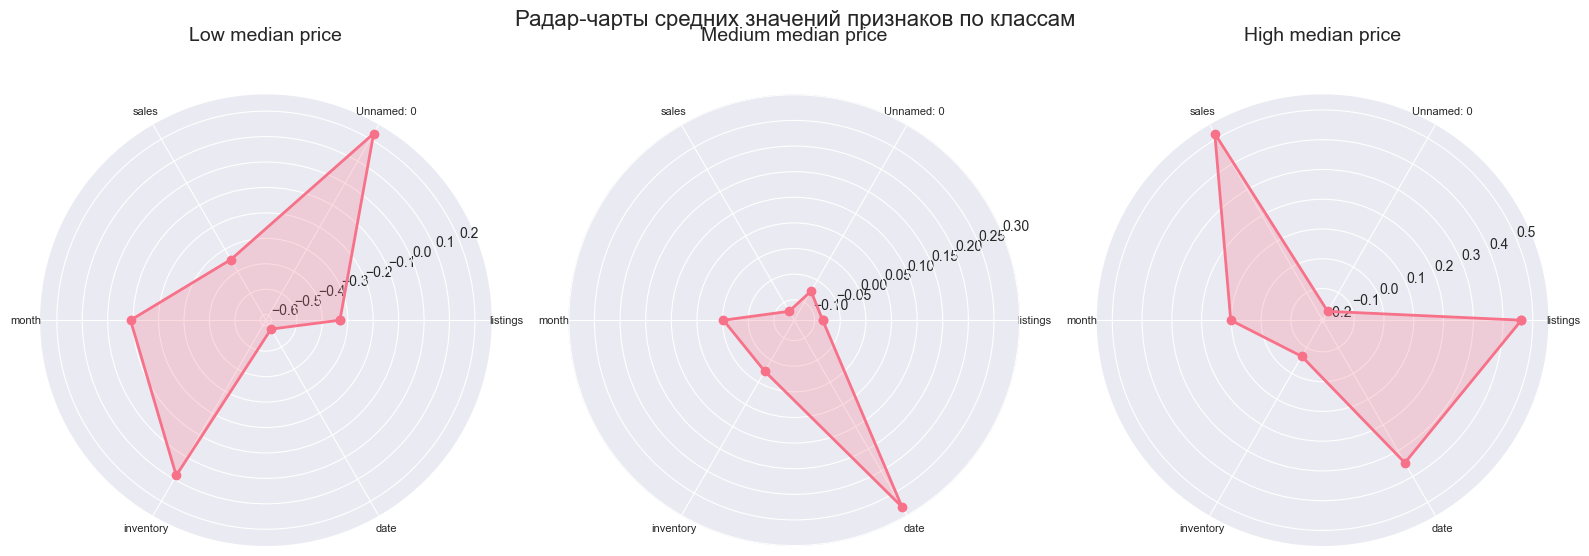


8. Интерактивная 3D визуализация (откроется в браузере)
  График сохранен в файл: interactive_3d_plot.html


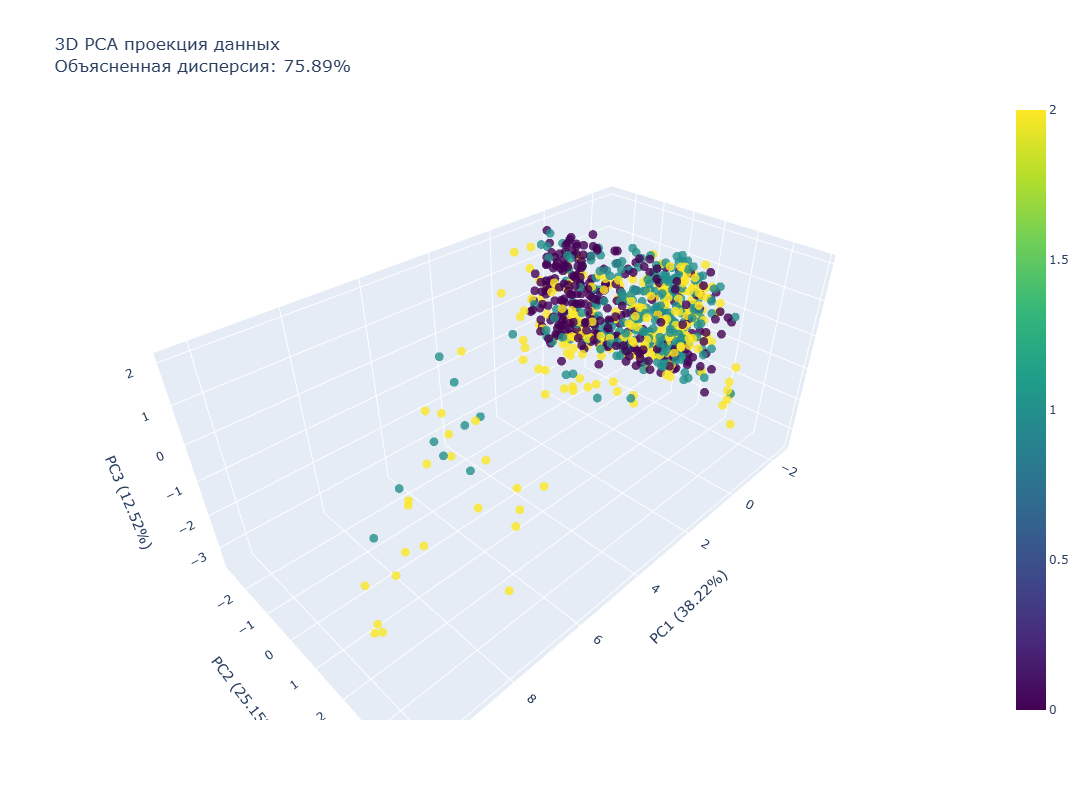


9. Сравнение методов уменьшения размерности
  Применяем PCA...
  Применяем t-SNE...
  Применяем Isomap...


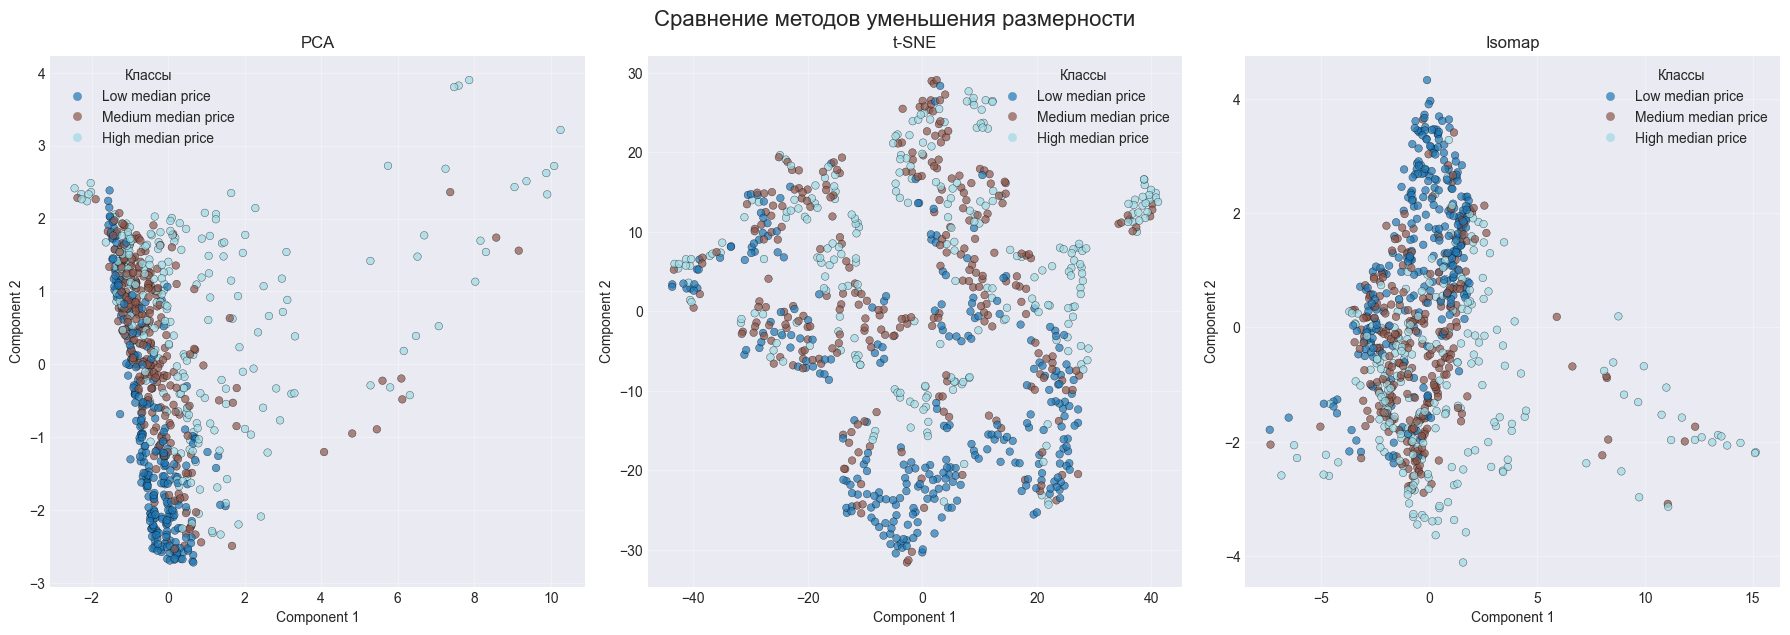


ВИЗУАЛИЗАЦИЯ ЗАВЕРШЕНА


In [18]:
from multidim_visualization import HighDimVisualizer

visualizer = HighDimVisualizer(random_state=42)

# Стратифицированная подвыборка только для визуализации.
max_viz_rows = 800
parts = []
for class_value, part in df.groupby('price_segment'):
    n = max(1, round(max_viz_rows * len(part) / len(df)))
    parts.append(part.sample(n=min(n, len(part)), random_state=42))

viz_df = pd.concat(parts).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Размер полного датасета после очистки: {df.shape}')
print(f'Размер подвыборки для визуализаций: {viz_df.shape}')
print(viz_df['price_segment'].value_counts().sort_index())

# Загрузка датасета и параметров в визуализатор.
# StandardScaler нужен, потому что признаки измеряются в разных масштабах:
# продажи, объём продаж, год, число активных объявлений, inventory и т.д.
visualizer.load_dataset(
    viz_df,
    target_column='price_segment',
    scaler=StandardScaler(),
    target_class_names=target_class_names_dict
)

# Запуск визуализации
visualizer.run_full_visualization()